# 03 — Final fitting, probability calibration and export
The chosen pipeline is refitted on training + validation. The later calibration block fits only a one-dimensional sigmoid calibration model, not the feature pipeline. The final test block is used once.

**Why calibration?** A classifier score is not automatically a trustworthy probability. Separate calibration allows checking Brier score, log loss and a reliability plot. It does not establish real-world food risk or future stability.

Do not retune the model, input set, threshold or calibration after seeing the final test report. A different development cycle needs a new untouched test period.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / "rasff_core.py").exists():
    raise FileNotFoundError("Open this notebook from the extracted RASFF_Rebuild folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from rasff_core import *

df = load_prepared()
blocks = temporal_blocks(df)

## 1. Evaluate once, or load the previously frozen result
A report already present in this folder is reused. If you change Notebook 02 settings, start a new experiment folder instead of silently overwriting the test result. Stored models should only be loaded from a trusted source.

In [2]:
if (ARTIFACTS / "test_report.json").exists():
    report = json.loads((ARTIFACTS / "test_report.json").read_text())
    current_spec = json.loads((ARTIFACTS / "selected_spec.json").read_text())
    if report["candidate"] != current_spec or report["source_sha256"] != json.loads((ARTIFACTS / "data_audit.json").read_text())["source_sha256"]:
        raise RuntimeError("Selection changed after final evaluation. Start a new experiment with an untouched test period.")
    bundle = joblib.load(ARTIFACTS / "final_bundle.joblib")
    print("Loaded the frozen evaluation; test data were not used to refit.")
else:
    bundle, report = fit_final(df)
display(pd.DataFrame({k:report[k] for k in ["calibrated","uncalibrated","prior_baseline"]}))
display(pd.DataFrame(report["confusion_matrix"],index=["Actual other","Actual serious"],columns=["Predicted other","Predicted serious"]))

Loaded the frozen evaluation; test data were not used to refit.


,calibrated,uncalibrated,prior_baseline
accuracy,0.765094,0.756851,0.461570
macro_f1,0.764917,0.756628,0.315804
serious_precision,0.721774,0.692029,0.461570
serious_recall,0.799107,0.852679,1.000000
average_precision,0.803260,0.803260,0.461570
roc_auc,0.844064,0.844064,0.500000
brier,0.162299,0.173766,0.259295
log_loss,0.495814,0.541445,0.711869
threshold,0.500000,0.500000,0.500000


,Predicted other,Predicted serious
Actual other,1923,690
Actual serious,450,1790


## 2. Inspect reliability, not just accuracy
The horizontal axis is mean predicted serious probability within bins; the vertical axis is the observed serious proportion. Sparse bins may be noisy. The data measure recorded labels among notified events, not safety in the general food population.

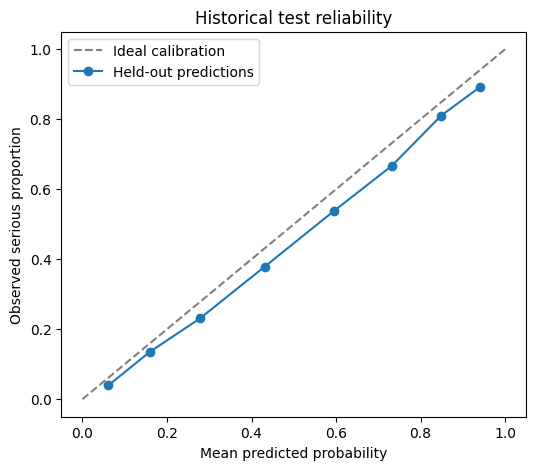

In [3]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
predictions = pd.read_csv(ARTIFACTS / "test_predictions.csv")
observed, predicted = calibration_curve(predictions.target,predictions.p_serious,n_bins=8,strategy="quantile")
fig,ax = plt.subplots(figsize=(6,5))
ax.plot([0,1],[0,1],"--",color="gray",label="Ideal calibration")
ax.plot(predicted,observed,"o-",label="Held-out predictions")
ax.set(xlabel="Mean predicted probability",ylabel="Observed serious proportion",title="Historical test reliability")
ax.legend();plt.show()

## 3. Review actual mistakes
The binary negative class includes undecided and potentially serious. Review original labels and text rather than interpreting every negative prediction as safe. Do not use this review to retrospectively improve the reported test score.

In [4]:
errors = predictions[predictions.target != predictions.prediction]
display(errors[["reference","date","subject","risk_decision","p_serious","prediction"]].head(20))
display(errors.risk_decision.value_counts().to_frame("Misclassified test records"))

,reference,date,subject,risk_decision,p_serious,prediction
19,2024.8741,2024-11-26 19:17:28,phenolic smell in shelled groundnuts,not serious,0.560515,1
23,2024.8746,2024-11-27 09:33:00,Presence of a foreign body in chocolate-flavor...,serious,0.446362,0
41,2024.8775,2024-11-27 16:47:33,High Level of Pyrrolizidine Alkaloids (PZA) (2...,potential risk,0.533325,1
42,2024.8776,2024-11-27 16:55:38,MOAH in Psyllium Husk,serious,0.485760,0
53,2024.8801,2024-11-28 13:41:01,High levels of afltoxin in dried figs from Turkey,potentially serious,0.888604,1
55,2024.8806,2024-11-28 14:57:50,Aflatoxins in black sunflower seeds from Turke...,potentially serious,0.863622,1
63,2024.8815,2024-11-28 15:41:37,Unauthorized substance chlorpyrifos-methyl in ...,serious,0.271773,0
77,2024.8834,2024-11-29 09:21:08,Foreign objects in candy from Sweden,potentially serious,0.646249,1
87,2024.8848,2024-11-29 11:58:07,Salmonella Typhimurium in the skin of turkey ...,potentially serious,0.594995,1
92,2024.8862,2024-11-29 14:47:48,vine leaves containing pesticides in quantitie...,serious,0.190268,0


,Misclassified test records
risk_decision,
serious,450
potentially serious,421
potential risk,173
not serious,82
no risk,14


## 4. Save and reload the entire prediction contract
The bundle contains preprocessing, classifier, sigmoid calibrator, feature list, threshold, scope and version metadata. The app reads this exact bundle. It does not reproduce the prediction with hand-written weights.

In [5]:
reloaded = joblib.load(ARTIFACTS / "final_bundle.joblib")
sample = blocks["test"].head(20)
a = predict_bundle(bundle,sample)
b = predict_bundle(reloaded,sample)
np.testing.assert_allclose(a,b)
print("Reloaded predictions match.")
print("Required fields:",bundle["columns"])
print("Transformed dimensions:",bundle["pipeline"].named_steps["preprocess"].transform(sample[bundle["columns"]]).shape[1])
print("Target:",bundle["target_definition"])
print("Scope:",bundle["scope"])

Reloaded predictions match.
Required fields: ['subject', 'origin', 'category', 'type', 'notifying_country', 'hazards']
Transformed dimensions: 8230
Target: 1 = recorded serious; 0 = all other known recorded labels (not safe).
Scope: Retrospective classification of notified events. No recall, contamination or general food safety probability.


## Blog notes
Compare with the earlier 87.36% only after explaining the changed data split, representation, calibration and evaluation. A lower corrected score does not mean the rebuild failed. No claim about concept drift should follow from label proportion changes alone.